In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("white")
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
print("Path to dataset files:", path)

/kaggle/input/-spotify-tracks-dataset/dataset.csv
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


In [2]:
file_path = '/kaggle/input/-spotify-tracks-dataset/dataset.csv'
df = pd.read_csv(file_path)

In [3]:
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.describe())

       Unnamed: 0  popularity  duration_ms  danceability     energy  \
count  114000.000  114000.000   114000.000    114000.000 114000.000   
mean    56999.500      33.239   228029.153         0.567      0.641   
std     32909.110      22.305   107297.713         0.174      0.252   
min         0.000       0.000        0.000         0.000      0.000   
25%     28499.750      17.000   174066.000         0.456      0.472   
50%     56999.500      35.000   212906.000         0.580      0.685   
75%     85499.250      50.000   261506.000         0.695      0.854   
max    113999.000     100.000  5237295.000         0.985      1.000   

             key   loudness       mode  speechiness  acousticness  \
count 114000.000 114000.000 114000.000   114000.000    114000.000   
mean       5.309     -8.259      0.638        0.085         0.315   
std        3.560      5.029      0.481        0.106         0.333   
min        0.000    -49.531      0.000        0.000         0.000   
25%        2.00

In [4]:
df = df.drop(columns=['Unnamed: 0'])
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

The top 10 artists are all renowned, with "The Beatles" being the most popular.

In [5]:
df=df.dropna()

In [6]:
df.isna().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
df=df.drop_duplicates()

In [8]:
df.shape

(113549, 20)

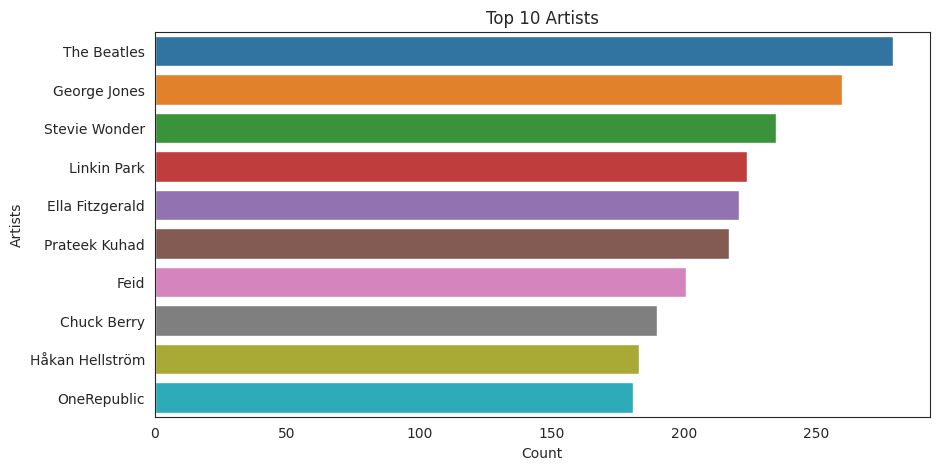

artists
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

In [9]:
plt.figure(figsize=(10, 5))
top_artists = df['artists'].value_counts().nlargest(10)
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title("Top 10 Artists")
plt.xlabel("Count")
plt.ylabel("Artists")
plt.show()
top_artists

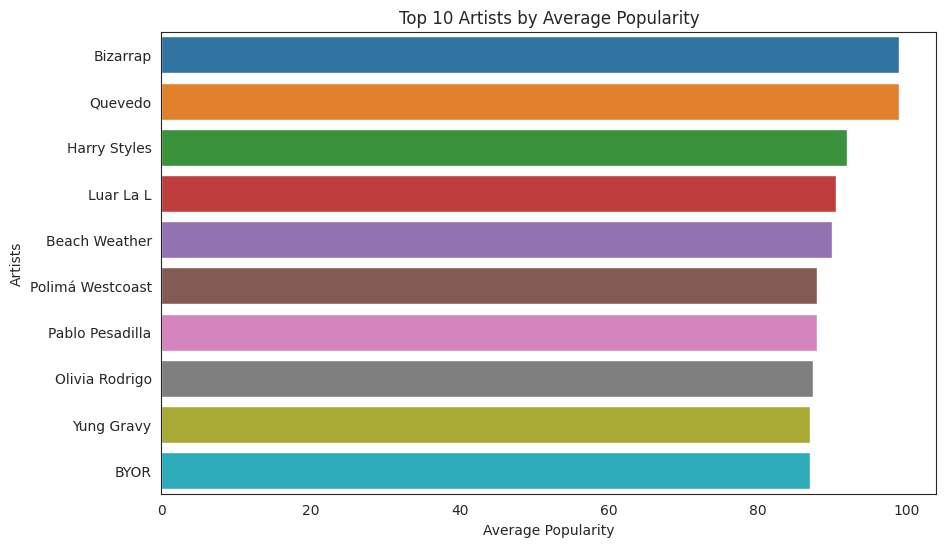

artists
Bizarrap           99.000
Quevedo            99.000
Harry Styles       92.000
Luar La L          90.500
Beach Weather      90.000
Polimá Westcoast   88.000
Pablo Pesadilla    88.000
Olivia Rodrigo     87.400
Yung Gravy         87.000
BYOR               87.000
Name: popularity, dtype: float64


In [10]:
copy_df = df.copy()
copy_df['artists'] = copy_df['artists'].str.split(';')
copy_df = copy_df.explode('artists')

top_artists = copy_df.groupby('artists')['popularity'].mean()
top_artists = top_artists[top_artists >= 70].sort_values(ascending=False)
top_artists_top10 = top_artists[:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists_top10.values, y=top_artists_top10.index)
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artists')
plt.show()

print(top_artists_top10)


 The top album and top track name are Halloween-themed and Christmas-themed

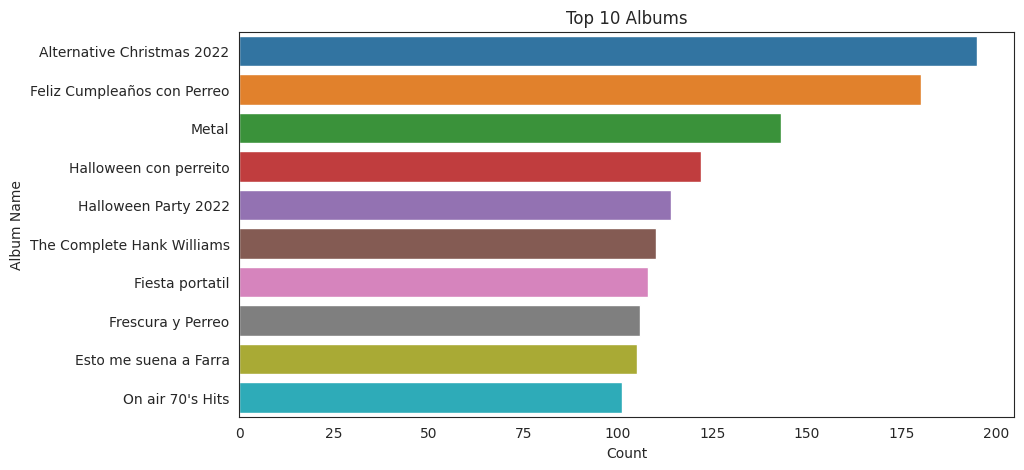

album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    180
Metal                          143
Halloween con perreito         122
Halloween Party 2022           114
The Complete Hank Williams     110
Fiesta portatil                108
Frescura y Perreo              106
Esto me suena a Farra          105
On air 70's Hits               101
Name: count, dtype: int64

In [11]:
plt.figure(figsize=(10, 5))
top_albums = df['album_name'].value_counts().nlargest(10)
sns.barplot(y=top_albums.index, x=top_albums.values)
plt.title("Top 10 Albums")
plt.xlabel("Count")
plt.ylabel("Album Name")
plt.show()
top_albums

The top 10 track genres are all popular genres, and they all appear with the same frequency

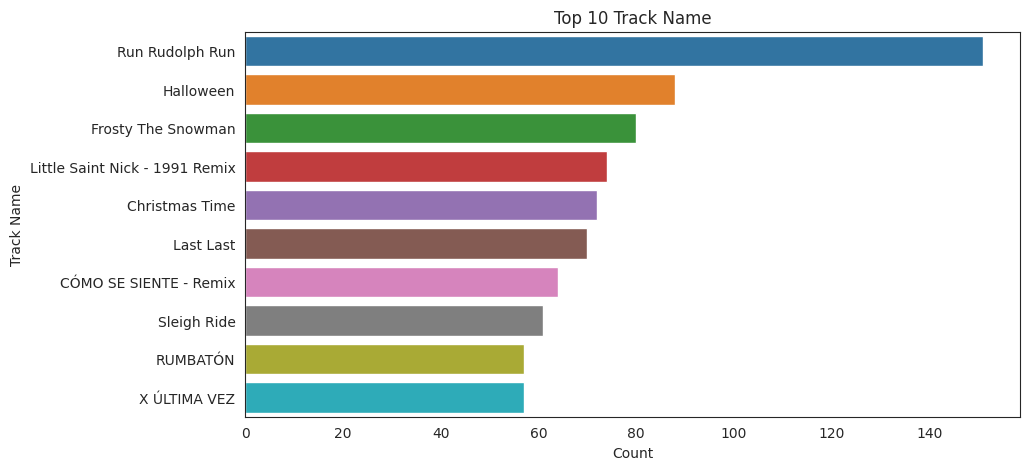

track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 80
Little Saint Nick - 1991 Remix     74
Christmas Time                     72
Last Last                          70
CÓMO SE SIENTE - Remix             64
Sleigh Ride                        61
RUMBATÓN                           57
X ÚLTIMA VEZ                       57
Name: count, dtype: int64

In [12]:
plt.figure(figsize=(10, 5))
top_artists = df['track_name'].value_counts().nlargest(10)
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title("Top 10 Track Name")
plt.xlabel("Count")
plt.ylabel("Track Name")
plt.show()
top_artists

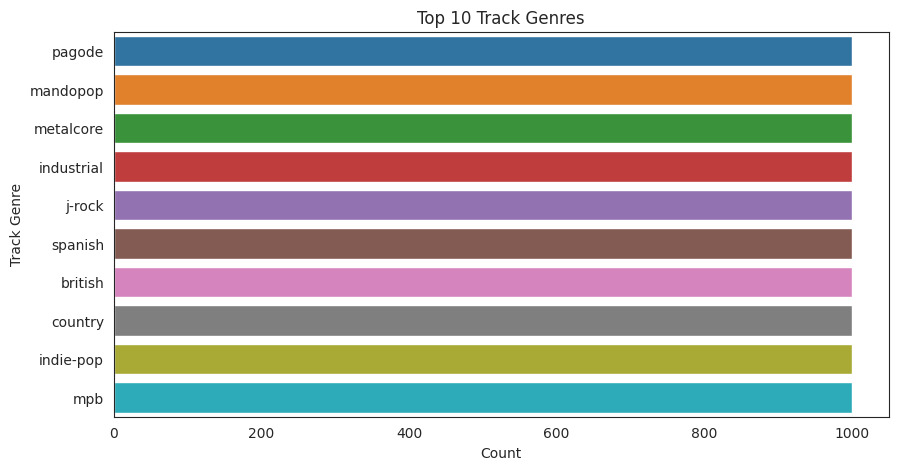

track_genre
pagode        1000
mandopop      1000
metalcore     1000
industrial    1000
j-rock        1000
spanish       1000
british       1000
country       1000
indie-pop     1000
mpb           1000
Name: count, dtype: int64

In [13]:
plt.figure(figsize=(10, 5))
top_genres = df['track_genre'].value_counts().nlargest(10)
sns.barplot(y=top_genres.index, x=top_genres.values)
plt.title("Top 10 Track Genres")
plt.xlabel("Count")
plt.ylabel("Track Genre")
plt.show()
top_genres

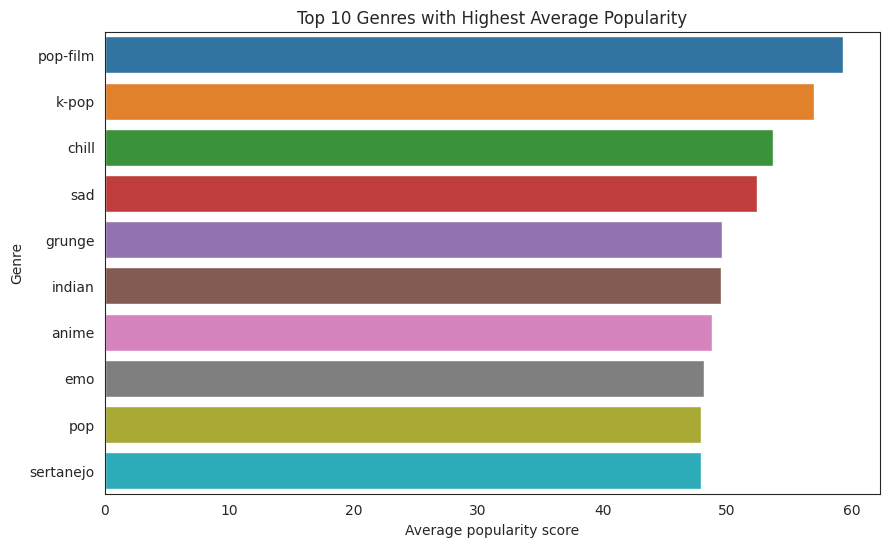

,track_genre,popularity
81,pop-film,59.280
65,k-pop,56.964
15,chill,53.705
94,sad,52.379
44,grunge,49.583
55,indian,49.529
5,anime,48.767
33,emo,48.128
80,pop,47.903
97,sertanejo,47.866


In [14]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().reset_index()
top10_popular_genres = avg_popularity_by_genre.nlargest(10, 'popularity')

plt.figure(figsize=(10, 6))
sns.barplot(x='popularity', y='track_genre', data=top10_popular_genres)
plt.title('Top 10 Genres with Highest Average Popularity')
plt.xlabel('Average popularity score')
plt.ylabel('Genre')
plt.show()

top10_popular_genres

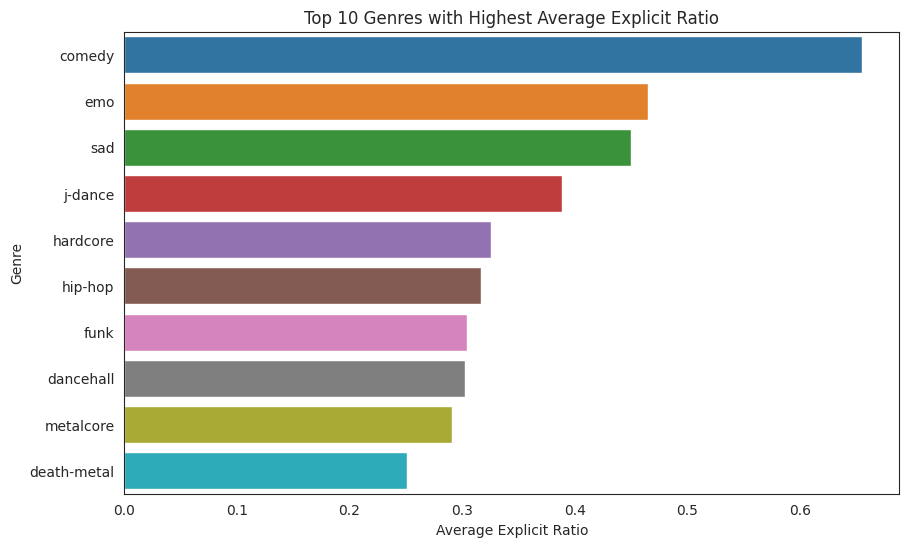

In [15]:
explicit_ratio_by_genre = df.groupby('track_genre')['explicit'].mean().reset_index()
top5_explicit_genres = explicit_ratio_by_genre.nlargest(10, 'explicit')

plt.figure(figsize=(10, 6))
sns.barplot(x='explicit', y='track_genre', data=top5_explicit_genres)
plt.title('Top 10 Genres with Highest Average Explicit Ratio')
plt.xlabel('Average Explicit Ratio')
plt.ylabel('Genre')
plt.show()

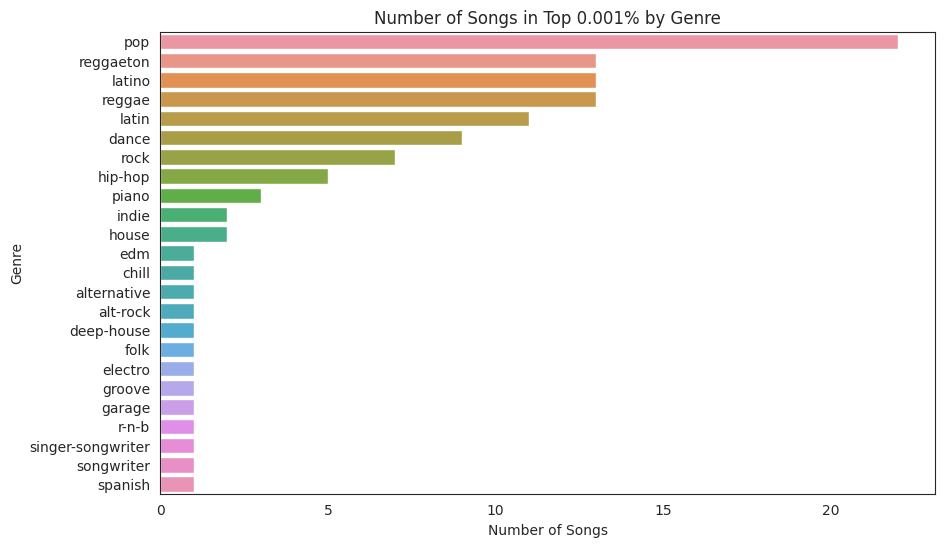

In [16]:
df_sorted = df.sort_values(by='popularity', ascending=False)
top_10_percent = df_sorted.head(int(0.001 * len(df_sorted)))
top_genres_count = top_10_percent.groupby('track_genre').size().reset_index(name='count')
top_genres_count = top_genres_count.sort_values(by='count', ascending=False)
most_common_genre = top_genres_count.loc[top_genres_count['count'].idxmax()]

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='track_genre', data=top_genres_count)
plt.title('Number of Songs in Top 0.001% by Genre')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.show()

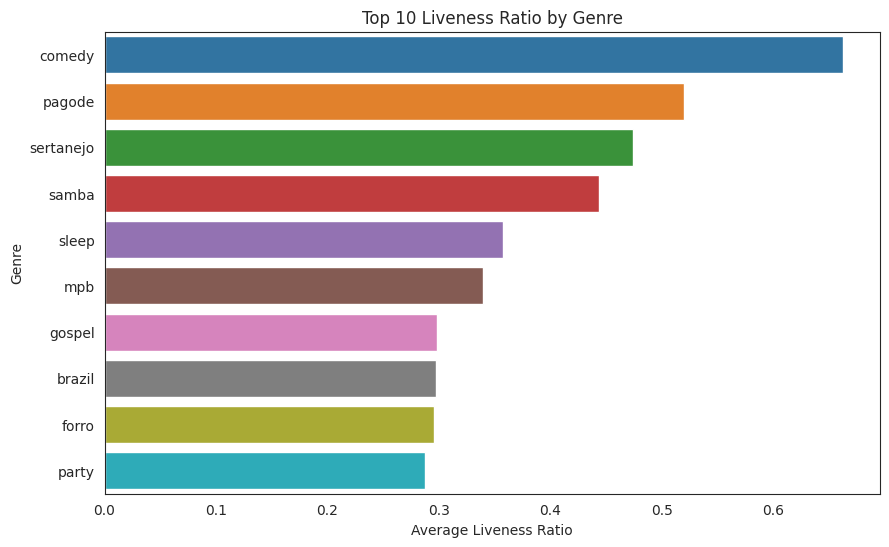

The genre with the highest liveness ratio is comedy with an average liveness ratio of 66.22%.


In [17]:
live_ratio_by_genre = df.groupby('track_genre')['liveness'].mean().reset_index()

top10_live_genres = live_ratio_by_genre.nlargest(10, 'liveness')
most_live_genre = live_ratio_by_genre.loc[live_ratio_by_genre['liveness'].idxmax()]

plt.figure(figsize=(10, 6))
sns.barplot(x='liveness', y='track_genre', data=top10_live_genres)
plt.title('Top 10 Liveness Ratio by Genre')
plt.xlabel('Average Liveness Ratio')
plt.ylabel('Genre')
plt.show()
print(f"The genre with the highest liveness ratio is {most_live_genre['track_genre']} with an average liveness ratio of {most_live_genre['liveness']:.2%}.")

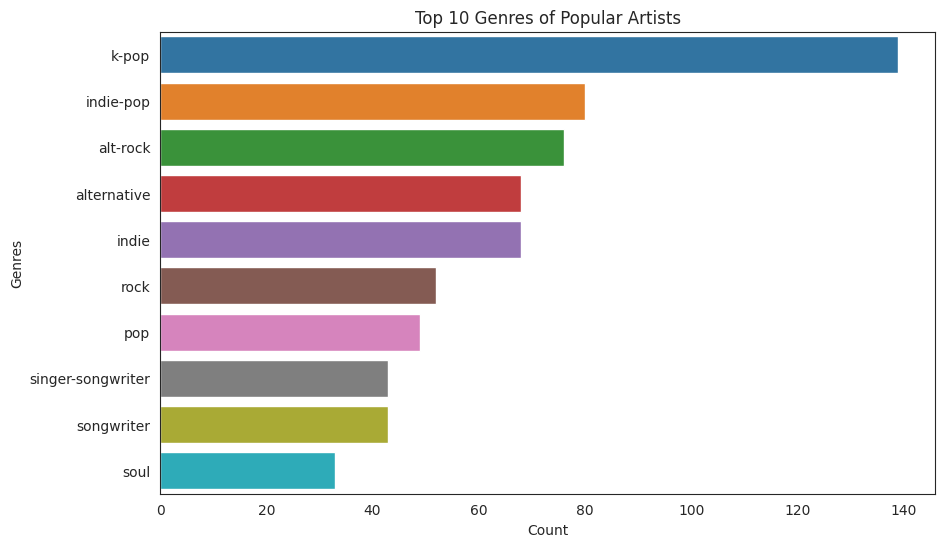

In [18]:
top_artists = copy_df.groupby('artists')['popularity'].mean()
top_artists = top_artists[top_artists >= 70].sort_values(ascending=False)
top_artists_list = top_artists.index.tolist()

genres_artists = df[df['artists'].isin(top_artists_list)]['track_genre'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genres_artists.values, y=genres_artists.index)
plt.title('Top 10 Genres of Popular Artists')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.show()


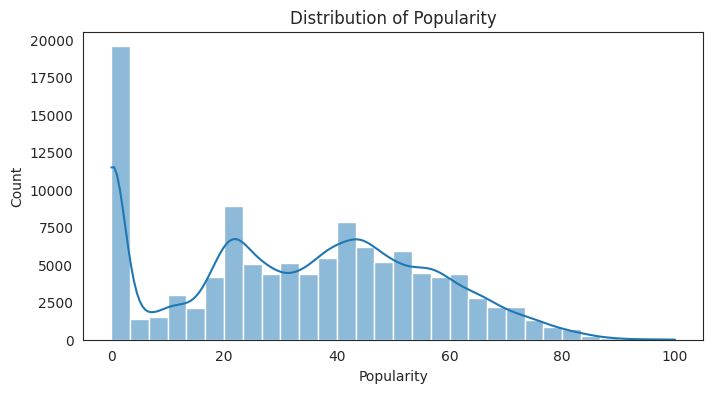

,Popularity,Count
0,0,15843
1,1,2116
2,2,1025
3,3,570
4,4,377
...,...,...
96,96,7
97,97,8
98,98,7
99,99,1


In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()
popularity_table = df['popularity'].value_counts().sort_index().reset_index()
popularity_table.columns = ['Popularity', 'Count']
popularity_table

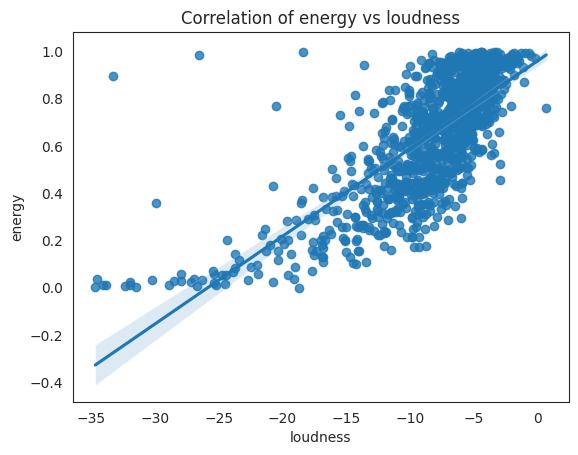

In [20]:
sample = df.sample(int(0.01 * len(df)))
sns.regplot(data=sample, y="energy", x="loudness")
plt.title("Correlation of energy vs loudness")
plt.show()

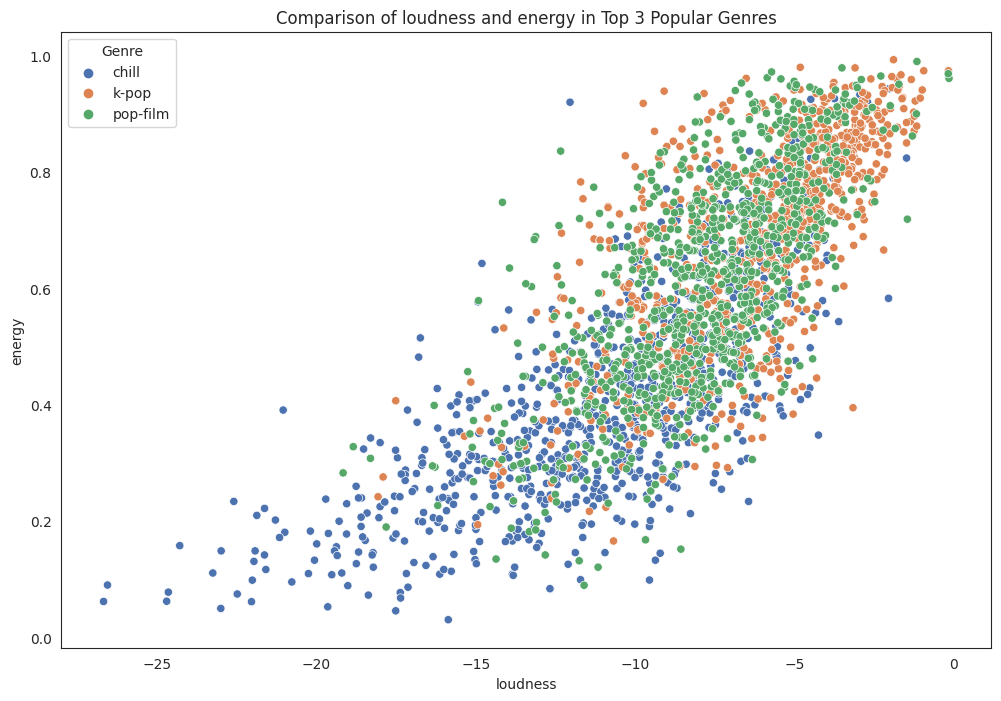

In [21]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().reset_index()
top3_popular_genres = avg_popularity_by_genre.nlargest(3, 'popularity')
top3_genre_data = df[df['track_genre'].isin(top3_popular_genres['track_genre'])]
plt.figure(figsize=(12, 8))
sns.scatterplot(x='loudness', y='energy', hue='track_genre', data=top3_genre_data, palette='deep')
plt.title('Comparison of loudness and energy in Top 3 Popular Genres')
plt.xlabel('loudness')
plt.ylabel('energy')
plt.legend(title='Genre')
plt.show()

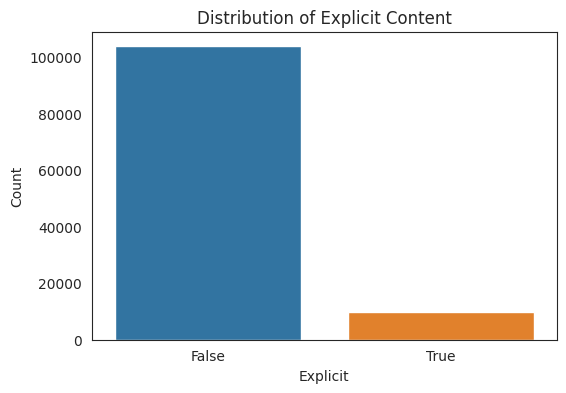

,Explicit,Count
0,False,103831
1,True,9718


In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['explicit'])
plt.title("Distribution of Explicit Content")
plt.xlabel("Explicit")
plt.ylabel("Count")
plt.show()
explicit_count_table = df['explicit'].value_counts().reset_index()
explicit_count_table.columns = ['Explicit', 'Count']
explicit_count_table

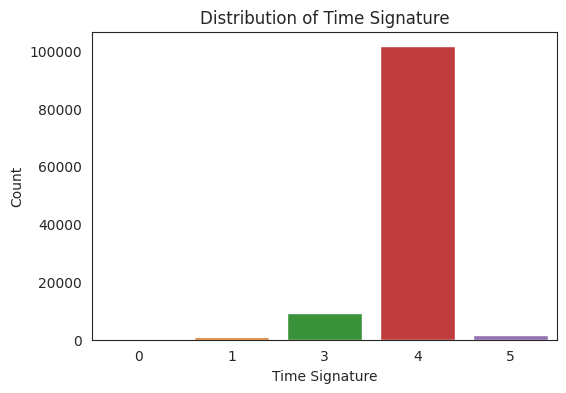

,Time Signature,Count
0,4,101486
1,3,9128
2,5,1805
3,1,967
4,0,163


In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['time_signature'])
plt.title("Distribution of Time Signature")
plt.xlabel("Time Signature")
plt.ylabel("Count")
plt.show()
time_signature_count_table = df['time_signature'].value_counts().reset_index()
time_signature_count_table.columns = ['Time Signature', 'Count']
time_signature_count_table

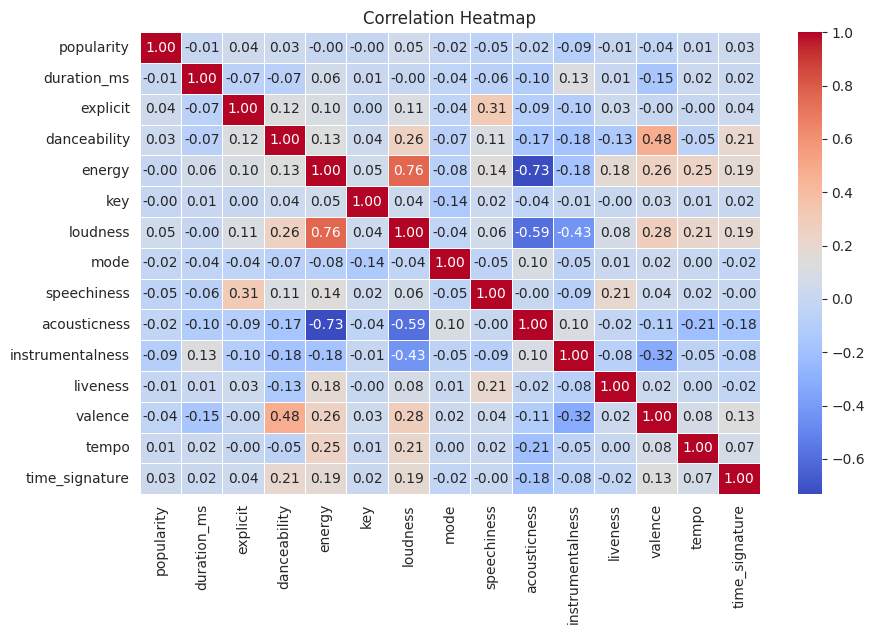

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

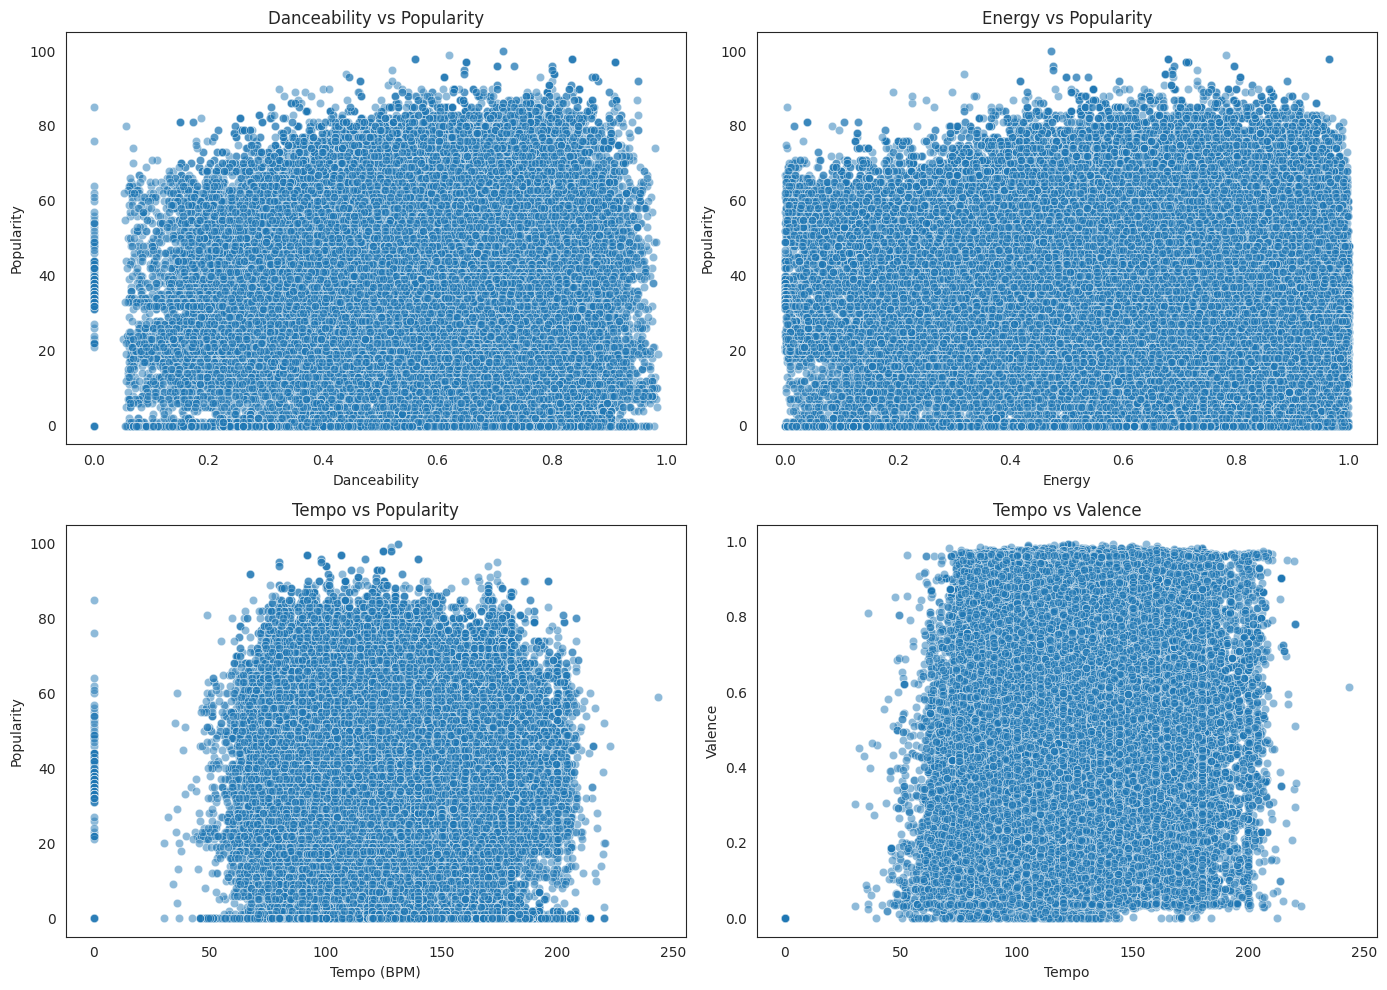

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Create 2x2 grid for 4 plots

# Danceability vs Popularity
sns.scatterplot(x=df["danceability"], y=df["popularity"], alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Danceability vs Popularity")
axes[0, 0].set_xlabel("Danceability")
axes[0, 0].set_ylabel("Popularity")

# Energy vs Popularity
sns.scatterplot(x=df["energy"], y=df["popularity"], alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Energy vs Popularity")
axes[0, 1].set_xlabel("Energy")
axes[0, 1].set_ylabel("Popularity")

# Tempo vs Popularity
sns.scatterplot(x=df["tempo"], y=df["popularity"], alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Tempo vs Popularity")
axes[1, 0].set_xlabel("Tempo (BPM)")
axes[1, 0].set_ylabel("Popularity")

# Tempo vs Valence
sns.scatterplot(x=df["tempo"], y=df["valence"], alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title("Tempo vs Valence")
axes[1, 1].set_xlabel("Tempo")
axes[1, 1].set_ylabel("Valence")

plt.tight_layout()
plt.show()
